### Mean-Variance Optimization under Fake stationary Rough Heston Volatility and Fractional Riccati Volterra Integral Equations(FRVIE).


- This notebook is a complementary material of [Gnab2026](https://arxiv.org/abs/2604.01300), authored by [Emmanuel Gnabeyeu](https://emma-gnabeyeu.github.io/). It illustrates the implementation of the fake stationary rough Heston model, the solution of inhomogeneous Riccati--Volterra equations, and the optimal strategy for the Markowitz portfolio selection problem under this framework, together with the evolution of the associated optimal wealth process.

- For further details, we refer the reader to [Gnab2026](https://arxiv.org/abs/2604.01300). The code is far from being optimized as it could be significantly improved through parallelisation. For any questions regarding the code or the paper, please feel free to reach out at emmanuel.gnabeyeu-mbiada@polytechnique.org.  I would be grateful for any feedback or suggestions to improve this notebook.

In [1]:
# Decorateur
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.special import gamma, gammainc
from scipy.stats import skew
from scipy.linalg import ldl
from scipy.linalg import cholesky
from scipy.integrate import quad
import scipy.integrate as integrate
from scipy.stats import norm
import scipy.special as sp
import scipy.sparse as sp_sparse
import time
from tqdm import tqdm

from scipy.optimize import minimize

from numpy.polynomial.legendre import leggauss


from numpy.random import default_rng, SeedSequence
import seaborn as sns
from scipy.optimize import fsolve, brentq

sns.set_theme()

sq = SeedSequence()
seed = sq.entropy       # on sauve la graine pour reproduire les résultats
print('seed = ', seed)
rng = default_rng(sq)
rng.standard_normal(5)

seed =  77929283751863177184164660760048791129


array([ 1.00018957, -1.69417158,  0.88905394,  1.21967766,  0.26346949])

## Resolvent $R_{\lambda, \alpha}(t)$ and its anti-derivative $f_{\lambda, \alpha}(t)$ for $\alpha \in (\frac12,1)$ for the Fractional integration kernel.


Let $K(t) = K_{\alpha}(t) = \frac{u^{\alpha-1}}{\Gamma(\alpha)} \mathbb{1}_{\mathbb{R}_+}(t),  \quad \alpha>0.$

This  family of  kernels corresponds to the fractional integrations of order $\alpha >0$.

It follows from the  easy identity  $K_{\alpha}*K_{\alpha'}= K_{\alpha+\alpha'}$ that

$$R_{\alpha,\lambda}(t) = \sum_{k\ge 0} (-1)^k \frac{\lambda ^k t^{\alpha k}}{\Gamma(\alpha k+1)}= E_{\alpha}(-\lambda t^{\alpha} ) \; t\ge 0,$$

where $E_{\alpha}$ denotes the standard   Mittag-Leffler function  

$E_{\alpha}(t) = \sum_{k\ge 0} \frac{t^k}{\Gamma(\alpha k+1)},\ t\!\in \mathbb{R}.$

If $\lambda >0$, the function $f_{\alpha, \lambda}$ defined on $(0,+\infty)$ by
$f_{\alpha, \lambda}(t) = - R'_{\alpha, \lambda}(t) = \alpha\lambda t^{\alpha-1} E'_{\alpha}(-\lambda t^{\alpha})  = \lambda t^{\alpha-1}\sum_{k\ge 0}(-1)^k\lambda^k \frac{t^{\alpha k}}{\Gamma(\alpha (k+1))}$

is a 1-sum measure and particularly if $\alpha>1$ , it is a probability density -- called Mittag-Leffler density -- since $f_{\alpha, \lambda}>0$ and $\displaystyle \int_0^{+\infty} f_{\alpha, \lambda}(t)dt =  R_{\alpha,\lambda}(0) - R_{\alpha,\lambda}(+\infty) = 1$.



- Exponential-Fractional integration kernel.

Let $K(t) = K_{\alpha,\rho}(t) = e^{-\rho t} \frac{u^{\alpha-1}}{\Gamma(\alpha)} \mathbb{1}_{\mathbb{R}_+}(t)$ with $\alpha, \rho>0 >0$.
Moreover
$K_{\alpha, \rho}*K_{\alpha', \rho}= K_{\alpha+\alpha',\rho}$ so that the resolvent reads
$ R_{\alpha, \rho, \lambda}(t)= e^{-\rho  t}R_{\alpha, 0,\lambda}(t).$


## Euler Maruyama Schemes for SVIEs

\begin{equation}
X_t= X_0R_{\lambda}(t) +\frac{1}{\lambda}\int_0^t f_{\lambda}(t-s)\mu(s)ds + \frac{1}{\lambda}\int_0^t f_{\lambda}(t-s)\sigma(s,X_s)dW_s.
\end{equation}

$$
\mu(t)= \mu_0\quad \mbox{ and }\quad \sigma(t,x)=\varsigma(t) \sigma(x),\quad  \varsigma(t), \;\sigma(x)>0.
$$

$b(x) = \mu_0-\lambda \, x$ and
$ \sigma(x) = \nu \sqrt{ x}\quad \mbox{ with }\quad  \nu\ge 0.$


First note that as $\mu(t)= \mu_0 $ and $R'_{\lambda}= -f_{\lambda} $, the equation reads

 $$ X_t= \Big(X_0-\frac{\mu_0}{\lambda}\Big) R_{\lambda}(t)+  \frac{1}{\lambda}\int_0^t f_{\lambda}(t-s)\sigma(s,X_s)dW_s.$$
 
Numerical Schemes:
$ \ [0,T]= \bigcup_{i=0}^{n-1} \ [t_i,t_{i+1}] $

We introduce an Euler's schemes with step $\frac Tn$ of the semi-integrated form above of the equation  (with $\mu(s)= \mu_0$ and noting that $\int_0^t f_{\lambda}(s)ds = 1-R_{\lambda}(t)$) namely, for every $k=0,\ldots,n$,

- Scheme 2
\begin{align*}
\bar X_{t_{k}} &= \frac{\mu_0}{\lambda} + \big(X_0 -\frac{\mu_0}{\lambda} \big)R_{\lambda}(t_k)+\frac{1}{\lambda}\sum_{\ell=1}^{k} \int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k-s)\varsigma(t_{\ell-1}) \sigma(\bar X_{t_{l-1}})dW_s \\
&= \frac{\mu_0}{\lambda} + \big(X_0 -\frac{\mu_0}{\lambda} \big)R_{\lambda}(t_k)+\frac{1}{\lambda}\sum_{\ell=1}^{k} \varsigma(t_{\ell-1}) \sigma(\bar{X}_{t_{\ell-1}}) I^{n,\ell}_k
\end{align*}

where $I^{n,\ell}_k = \int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k - s) \, dW_s,$

We will first retrieve or simulate these quantities $\int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k-s)\varsigma(t_{\ell-1}) \sigma(\bar X_{t_{l-1}})dW_s$ by designing a vector $(\Delta W_l, \int_{t_{\ell-1}}^{t_\ell} f_{\lambda}(t_k-s)dW_s,....)$ and using cholesky decomposition


- Scheme 3
\begin{align*}
\bar X_{t_{k}} &= X_0 + \frac{1}{\Gamma(\alpha)}\sum_{\ell=1}^{k} \int_{t_{\ell-1}}^{t_\ell} (t_k-s)^{\alpha-1}(\mu_0 - \lambda X_{t_{l-1}})ds + \frac{1}{\Gamma(\alpha)}\sum_{\ell=1}^{k} \int_{t_{\ell-1}}^{t_\ell} (t_k-s)^{\alpha-1}\varsigma(t_{\ell-1}) \sigma(\bar X_{t_{l-1}})dW_s \\ &=
 \big(\frac{T}{n}\big)^{\alpha} \frac{1}{\alpha\Gamma(\alpha)}\sum_{\ell=1}^{k} (\mu_0 - \lambda X_{t_{l-1}}) \big[(k-l+1)^{\alpha}-(k-l)^{\alpha}\big] + \frac{1}{\Gamma(\alpha)}\sum_{\ell=1}^{k} \varsigma(t_{\ell-1}) \sigma(\bar X_{t_{l-1}}) \int_{t_{\ell-1}}^{t_\ell} (t_k-s)^{\alpha-1}dW_s \\
 &= \big(\frac{T}{n}\big)^{\alpha} \frac{1}{\alpha\Gamma(\alpha)}\sum_{\ell=1}^{k} (\mu_0 - \lambda X_{t_{k-l}}) \big[l^{\alpha}-(l-1)^{\alpha}\big] + \frac{1}{\Gamma(\alpha)}\sum_{\ell=1}^{k} \varsigma(t_{\ell-1}) \sigma(\bar X_{t_{l-1}})\int_{t_{\ell-1}}^{t_\ell} (t_k-s)^{\alpha-1}dW_s \\
\end{align*}


In [3]:
# import VolterraSDEsWith_Stabilizer as vsw
from VolterraSDEsWith_Stabilizer import StochasticProcessSimulator
from VolterraSDEsWith_Stabilizer import FakeStationaryVolterraModel

seed =  257446506423616647156723395642818489043


## Compute and plot the evolution of the Volatilities processes

In [5]:
# Instantiate and run the simulator
N = 600 # Number of steps
M= 1000 # Simulation size
H=0.1
rho = -0.6714
mu_01 =  2.0 # 5*0.04 # 0.08 # 
lambda_ = 0.2 # 5 # 0.2
nu = 0.4 # 1 0.05 # lambda= 2, ρ = −0.5, V0 = 0.4, ν = 0.05, θ = 0.04.
center1 = mu_01 / lambda_
# v0= 0.09

T = 1.0
S0 = 100

sigma_x = lambda x : nu*np.sqrt(x) # 
func_latex = r'$\sigma(x) = \nu \sqrt{x}$'
expect_sigma_0_1 = nu**2*mu_01/lambda_
c = 0.01 # 0.036
v01 = c*nu**2*mu_01 / lambda_

nmax = 25 # 75 # Number of terms in the Tauberian expansion

# Define the distribution for X0
X0_distribution = {
        'type': 'normal',  # Specify the type of distribution (e.g., 'normal' or 'uniform'), then the its parameters
        'mean': center1,
        'std': np.sqrt(v01),
    }
config = {
    'mu_0' : mu_01,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'rho'   : rho,
    'sigma_x' : sigma_x,
    'v0' : v01,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'c'  : c,
    'expect_sigma_0_2': expect_sigma_0_1,
    'nmax'   : nmax,
    'X0_distribution': X0_distribution,
    'scheme' : 2,
    'VCV' : None, # {'T_expanded': T_expanded,'D_expanded':D_expanded}, # if save in disk, default is None 
    'VCV2' : None, # {'T_expanded_2':T_expanded_2,'D_expanded_2':D_expanded_2}, # if save in disk, default is None 
    'S0' : S0,
    'func_latex' : func_latex, 
    'plt_ylimVarX': [np.sqrt(v01)-0.03, np.sqrt(v01)+0.03],
    'plt_ylimSigma': [expect_sigma_0_1-0.03, expect_sigma_0_1+0.03], # [9.97, 10.03], # [0.97, 0.13],
    # Run simulations (e.g., path generation, stochastic process simulations) or Perform statistical analysis (e.g., gather means, variances, etc.)
    'experiment_type': 'simulation'  # or 'statistical_analysis'
}     

In [7]:
# Instantiate and run the simulator
config['alpha'] = 0.5 + 0.1
config['T'] =1
# config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H010.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H010.npz').toarray()}
config['X0_distribution']= {'type': 'normal', 'mean': center1, 'std': np.sqrt(v01)}
simulator = StochasticProcessSimulator(config, random_state=rng)

computing tauberian coefficients


100%|████████████████████████████████████████| 24/24 [00:00<00:00, 82040.18it/s]

done: Rayon > T : Yes, [Rayon, T] = [92.46077286544161, 1]


Simulating trajectories, scheme 2


100%|████████████████████████████████████████| 600/600 [00:01<00:00, 485.47it/s]
/tmp/ipykernel_391285/3386343035.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_391285/3386343035.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


done


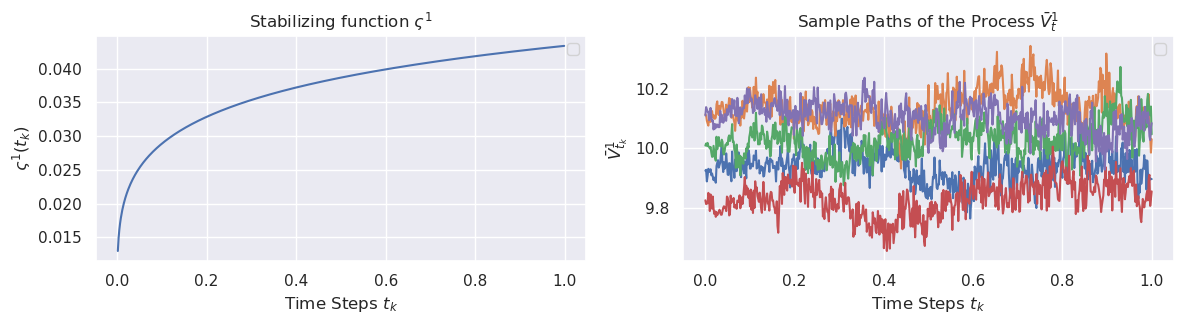

In [9]:
t_values = np.arange(1,simulator.n)*simulator.dt  # Time points to evaluate ζ(t)
# Compute coefficients c_k
zeta_values = simulator.zeta_t(t_values, simulator.c_coeffs)

X, sigma_vals, increments = simulator.simulate_path_cholesky_expanded()

# Create two vertical subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

axes[0].plot(t_values, zeta_values) # , label="Stabilizing function $\varsigma^1$")
axes[0].set_xlabel("Time Steps $t_k$")
axes[0].set_ylabel(r"$\varsigma^1(t_k)$")
axes[0].set_title(r"Stabilizing function $ \varsigma^1$")
axes[0].legend()
# plt.title('Stabilizer function ζ(t)')
        
# Randomly select `n_trajectories` indices
n_trajectories = 5 # 50
indices = np.random.choice(simulator.M, n_trajectories, replace=False)
for m in indices:  # Iterate over the randomly selected indices
    axes[1].plot(simulator.times, X[:, m]) # , label=f"Trajectory {m + 1}")
axes[1].set_xlabel("Time Steps $t_k$")
axes[1].set_ylabel(r"$\bar{V}^1_{t_k}$")
axes[1].set_title(r"Sample Paths of the Process $\bar{V}^1_{t}$")
axes[1].legend()

# fig.suptitle(r'Curves $\text{Var}(X_t)$ and $\mathbb{E}[ \sigma^2(X_t) ]$  as function of time,'+ self.func_latex + f', H={np.round(self.alpha-0.5,2)}, c= {np.round(self.c,3)}, {"{:.1e}".format(self.M)} Samples, scheme = {self.scheme}, '+ r' $X_0$' + f'={self.X0_distribution['type']}', fontsize=16)
# Adjust layout for better spacing between subplots
plt.tight_layout()
# Save the figure
plt.savefig(f'Stabilizer_Samplepaths_H0{int(np.round(100*(simulator.alpha-0.5),2))}_T{int(simulator.T)}.pdf')  # Sauvegarder sous le nom souhaité
# Display the figure
plt.show() 

In [11]:
def plot_variance_meansigma_curves(simulator, expectation_sigma_square, variances):
    """
    Compute the sample variance for each time step t_k across M realizations of X,
    and the expectation of the square of the second argument.

    Parameters:
    X (ndarray): Array of shape (n, M), where n is the number of time steps and M is the number of realizations.
    sigma_vals (ndarray): Array of shape (n+1, M) for the second argument whose square we want to compute the expectation.

    Returns:
    None (plots the figure with two subplots)
    """
    # Create two vertical subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # First subplot: Plotting the variance of X
    axes[0].plot(simulator.times, variances, label="Variance of $V^1_{t_k}$", color='green')
    if simulator.experiment_type == 'simulation':
        std_0 = simulator.v0 # np.sqrt(simulator.v0)
        axes[0].axhline(y= std_0, color='red', linestyle='--', label=f"Benchmark $Var(V^1_0)$ = {std_0}") # Benchmark $std(X_0)$ = {std_0}
    else:
        std_0= np.mean(variances[-20:]) # np.mean(np.sqrt(variances)[-20:])
        axes[0].axhline(y= std_0, color='red', linestyle='--', label=f"Target asymtotic $Var(V^1_0)$ = {np.round(std_0,3)}") # Benchmark $std(X_0)$ = {std_0}
        
    axes[0].set_ylim(tuple( [simulator.v0-0.004, simulator.v0+0.004]))
    axes[0].set_xlabel("Time Steps $t_k$")
    axes[0].set_ylabel(r" $\text{Var}(t_k, M)$")
    # axes[0].set_ylabel(r"$\text{Var}(V_{t_k}, M)$") # axes[0].set_ylabel(r"Std $\sqrt{\text{Var}(t_k, M)}$")
    axes[0].set_title(r"Sample Variance $\text{Var}(V^1_t)$")
    axes[0].legend()
    axes[0].grid(True)
    # Second subplot: Plotting the expectation of the square of the second argument
    axes[1].plot(simulator.times, expectation_sigma_square, label=r"$\mathbb{E}[\sigma^2(V^1_t)]$", color='green')
    if simulator.experiment_type == 'simulation':
        axes[1].axhline(y=simulator.expect_sigma_0_2, color='red', linestyle='--', label=r"Benchmark $\mathbb{E}[\sigma^2(V^1_0)]$"+f"= {np.round(simulator.expect_sigma_0_2,3)}")
    else:
        expect_sigma_0_2 = np.mean(expectation_sigma_square[-20:])
        axes[1].axhline(y= expect_sigma_0_2, color='red', linestyle='--', label=r"Target asymtotic $\mathbb{E}[\sigma^2(V^1_t)]$"+f"= {np.round(expect_sigma_0_2,3)}") # 
    axes[1].set_ylim(tuple([simulator.expect_sigma_0_2-0.004, simulator.expect_sigma_0_2+0.004]))
    axes[1].set_xlabel("Time Steps $t_k$")
    axes[1].set_ylabel(r"$\mathbb{E}[ \sigma^2(V^1_t) ]$")
    axes[1].set_title(r"Expectation of $\sigma^2(V^1_t)$")
    axes[1].legend()
    axes[1].grid(True)
    # Add a global title
    fig.suptitle(r'Curves $\text{Var}(V^1_t)$ and $\mathbb{E}[ \sigma^2(V^1_t) ]$  as a function of time, '+ simulator.func_latex + r', $\nu=$'+ f'{nu},  H={np.round(simulator.alpha-0.5,2)}, c= {np.round(simulator.c,3)}', fontsize=16) # {"{:.1e}".format(simulator.M)} Samples, scheme = {self.scheme}, '+ r' $X_0$' + f'={self.X0_distribution['type']}', fontsize=16)
    # Adjust layout for better spacing between subplots
    plt.tight_layout()
    # Save the figure
    plt.savefig(f'curves_variance_meansigma_scheme{simulator.scheme}_H0{int(np.round(100*(simulator.alpha-0.5),2))}_T{int(simulator.T)}.pdf')  # Sauvegarder sous le nom souhaité
    # Display the figure
    plt.show()

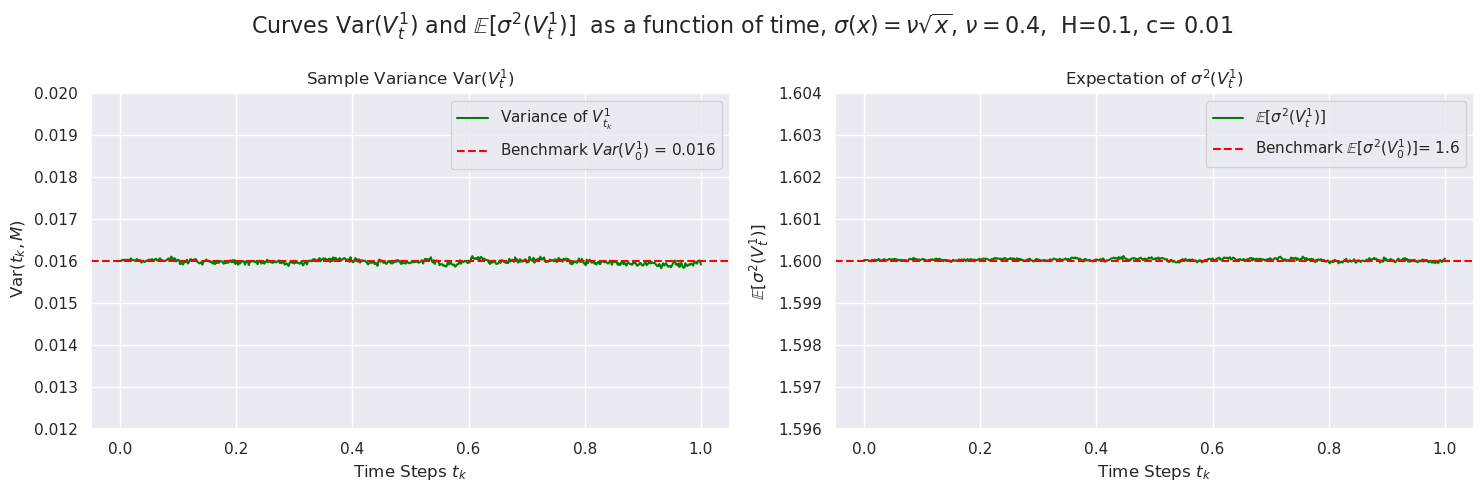

In [67]:
simulator.M = 80000
simulator.scheme = 2
expectation_sigma_square, variances, _, _ = simulator.simulate_batches_compute_moments_plot_trajectories(total_batches=40)
plot_variance_meansigma_curves(simulator, expectation_sigma_square, variances)

In [13]:
# Instantiate and run the simulator
N = 600 # Number of steps
M= 1000 # Simulation size
H=0.4
rho = -0.55
mu_02 = 1 # 5*0.04 # 0.08 # 
lambda_ = 0.2 # 5 # 0.2
nu = 0.32 # 0.3 # 1 0.05 # lambda= 2, ρ = −0.5, V0 = 0.4, ν = 0.05, θ = 0.04.
center2 = mu_02 / lambda_
# v0= 0.09

T = 1.0
S0 = 100

sigma_x = lambda x : nu*np.sqrt(x) # 
func_latex = r'$\sigma(x) = \nu \sqrt{x}$'
expect_sigma_0_2 = nu**2*mu_02/lambda_
c = 0.03 #  0.03 # 0.012 # 0.036
v02 = c*nu**2*center2

nmax = 75 # Number of terms in the Tauberian expansion

# Define the distribution for X0
X0_distribution = {
        'type': 'normal',  # Specify the type of distribution (e.g., 'normal' or 'uniform'), then the its parameters
        'mean': center2,
        'std': np.sqrt(v02),
    }
config = {
    'mu_0' : mu_02,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'rho'   : rho,
    'sigma_x' : sigma_x,
    'v0' : v02,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'c'  : c,
    'expect_sigma_0_2': expect_sigma_0_2,
    'nmax'   : nmax,
    'X0_distribution': X0_distribution,
    'scheme' : 2,
    'VCV' : None, # {'T_expanded': T_expanded,'D_expanded':D_expanded}, # if save in disk, default is None 
    'VCV2' : None, # {'T_expanded_2':T_expanded_2,'D_expanded_2':D_expanded_2}, # if save in disk, default is None 
    'S0' : S0,
    'func_latex' : func_latex, 
    'plt_ylimVarX': [np.sqrt(v02)-0.03, np.sqrt(v02)+0.03],
    'plt_ylimSigma': [expect_sigma_0_2-0.03, expect_sigma_0_2+0.03], # [9.97, 10.03], # [0.97, 0.13],
    # Run simulations (e.g., path generation, stochastic process simulations) or Perform statistical analysis (e.g., gather means, variances, etc.)
    'experiment_type': 'simulation'  # or 'statistical_analysis'
}     

In [15]:
# Instantiate and run the simulator
config['alpha'] = 0.5 + 0.4
config['T'] =1
# config['c'] =0.012
config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}
# config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H010.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H010.npz').toarray()}
config['X0_distribution']= {'type': 'normal', 'mean': center2, 'std': np.sqrt(v02)}
simulator = StochasticProcessSimulator(config, random_state=rng)

computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 35003.78it/s]

done: Rayon > T : Yes, [Rayon, T] = [125.78637485851324, 1]


Simulating trajectories, scheme 2


100%|███████████████████████████████████████| 600/600 [00:00<00:00, 1374.09it/s]
/tmp/ipykernel_584853/432240612.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_584853/432240612.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


done


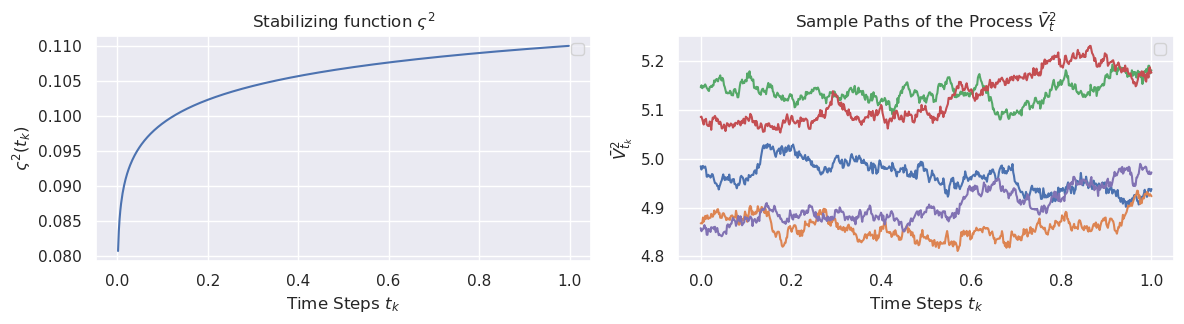

In [68]:
t_values = np.arange(1,simulator.n)*simulator.dt  # Time points to evaluate ζ(t)
# Compute coefficients c_k
zeta_values = simulator.zeta_t(t_values, simulator.c_coeffs)

X, sigma_vals, increments = simulator.simulate_path_cholesky_expanded()

# Create two vertical subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

axes[0].plot(t_values, zeta_values) # , label="Stabilizing function $\varsigma^1$")
axes[0].set_xlabel("Time Steps $t_k$")
axes[0].set_ylabel(r"$\varsigma^2(t_k)$")
axes[0].set_title(r"Stabilizing function $ \varsigma^2$")
axes[0].legend()
# plt.title('Stabilizer function ζ(t)')
        
# Randomly select `n_trajectories` indices
n_trajectories = 5 # 50
indices = np.random.choice(simulator.M, n_trajectories, replace=False)
for m in indices:  # Iterate over the randomly selected indices
    axes[1].plot(simulator.times, X[:, m]) # , label=f"Trajectory {m + 1}")
axes[1].set_xlabel("Time Steps $t_k$")
axes[1].set_ylabel(r"$\bar{V}^2_{t_k}$")
axes[1].set_title(r"Sample Paths of the Process $\bar{V}^2_{t}$")
axes[1].legend()

# fig.suptitle(r'Curves $\text{Var}(X_t)$ and $\mathbb{E}[ \sigma^2(X_t) ]$  as function of time,'+ self.func_latex + f', H={np.round(self.alpha-0.5,2)}, c= {np.round(self.c,3)}, {"{:.1e}".format(self.M)} Samples, scheme = {self.scheme}, '+ r' $X_0$' + f'={self.X0_distribution['type']}', fontsize=16)
# Adjust layout for better spacing between subplots
plt.tight_layout()
# Save the figure
plt.savefig(f'Stabilizer_Samplepaths_H0{int(np.round(100*(simulator.alpha-0.5),2))}_T{int(simulator.T)}.pdf')  # Sauvegarder sous le nom souhaité
# Display the figure
plt.show() 

In [17]:
def plot_variance_meansigma_curves(simulator, expectation_sigma_square, variances):
    """
    Compute the sample variance for each time step t_k across M realizations of X,
    and the expectation of the square of the second argument.

    Parameters:
    X (ndarray): Array of shape (n, M), where n is the number of time steps and M is the number of realizations.
    sigma_vals (ndarray): Array of shape (n+1, M) for the second argument whose square we want to compute the expectation.

    Returns:
    None (plots the figure with two subplots)
    """
    # Create two vertical subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # First subplot: Plotting the variance of X
    axes[0].plot(simulator.times, variances, label="Variance of $V^2_{t_k}$", color='green')
    if simulator.experiment_type == 'simulation':
        std_0 = simulator.v0 # np.sqrt(simulator.v0)
        axes[0].axhline(y= std_0, color='red', linestyle='--', label=f"Benchmark $Var(V^2_0)$ = {std_0}") # Benchmark $std(X_0)$ = {std_0}
    else:
        std_0= np.mean(variances[-20:]) # np.mean(np.sqrt(variances)[-20:])
        axes[0].axhline(y= std_0, color='red', linestyle='--', label=f"Target asymtotic $Var(V^2_0)$ = {np.round(std_0,3)}") # Benchmark $std(X_0)$ = {std_0}
        
    axes[0].set_ylim(tuple( [simulator.v0-0.004, simulator.v0+0.004]))
    axes[0].set_xlabel("Time Steps $t_k$")
    axes[0].set_ylabel(r" $\text{Var}(t_k, M)$")
    # axes[0].set_ylabel(r"$\text{Var}(V_{t_k}, M)$") # axes[0].set_ylabel(r"Std $\sqrt{\text{Var}(t_k, M)}$")
    axes[0].set_title(r"Sample Variance $\text{Var}(V^2_t)$")
    axes[0].legend()
    axes[0].grid(True)
    # Second subplot: Plotting the expectation of the square of the second argument
    axes[1].plot(simulator.times, expectation_sigma_square, label=r"$\mathbb{E}[\sigma^2(V^2_t)]$", color='green')
    if simulator.experiment_type == 'simulation':
        axes[1].axhline(y=simulator.expect_sigma_0_2, color='red', linestyle='--', label=r"Benchmark $\mathbb{E}[\sigma^2(V^2_0)]$"+f"= {np.round(simulator.expect_sigma_0_2,3)}")
    else:
        expect_sigma_0_2 = np.mean(expectation_sigma_square[-20:])
        axes[1].axhline(y= expect_sigma_0_2, color='red', linestyle='--', label=r"Target asymtotic $\mathbb{E}[\sigma^2(V^2_t)]$"+f"= {np.round(expect_sigma_0_2,3)}") # 
    axes[1].set_ylim(tuple([simulator.expect_sigma_0_2-0.004, simulator.expect_sigma_0_2+0.004]))
    axes[1].set_xlabel("Time Steps $t_k$")
    axes[1].set_ylabel(r"$\mathbb{E}[ \sigma^2(V^2_t) ]$")
    axes[1].set_title(r"Expectation of $\sigma^2(V^2_t)$")
    axes[1].legend()
    axes[1].grid(True)
    # Add a global title
    fig.suptitle(r'Curves $\text{Var}(V^2_t)$ and $\mathbb{E}[ \sigma^2(V^2_t) ]$  as a function of time, '+ simulator.func_latex + r', $\nu=$'+ f'{nu},  H={np.round(simulator.alpha-0.5,2)}, c= {np.round(simulator.c,3)}', fontsize=16) # {"{:.1e}".format(simulator.M)} Samples, scheme = {self.scheme}, '+ r' $X_0$' + f'={self.X0_distribution['type']}', fontsize=16)
    # Adjust layout for better spacing between subplots
    plt.tight_layout()
    # Save the figure
    plt.savefig(f'curves_variance_meansigma_scheme{simulator.scheme}_H0{int(np.round(100*(simulator.alpha-0.5),2))}_T{int(simulator.T)}.pdf')  # Sauvegarder sous le nom souhaité
    # Display the figure
    plt.show()

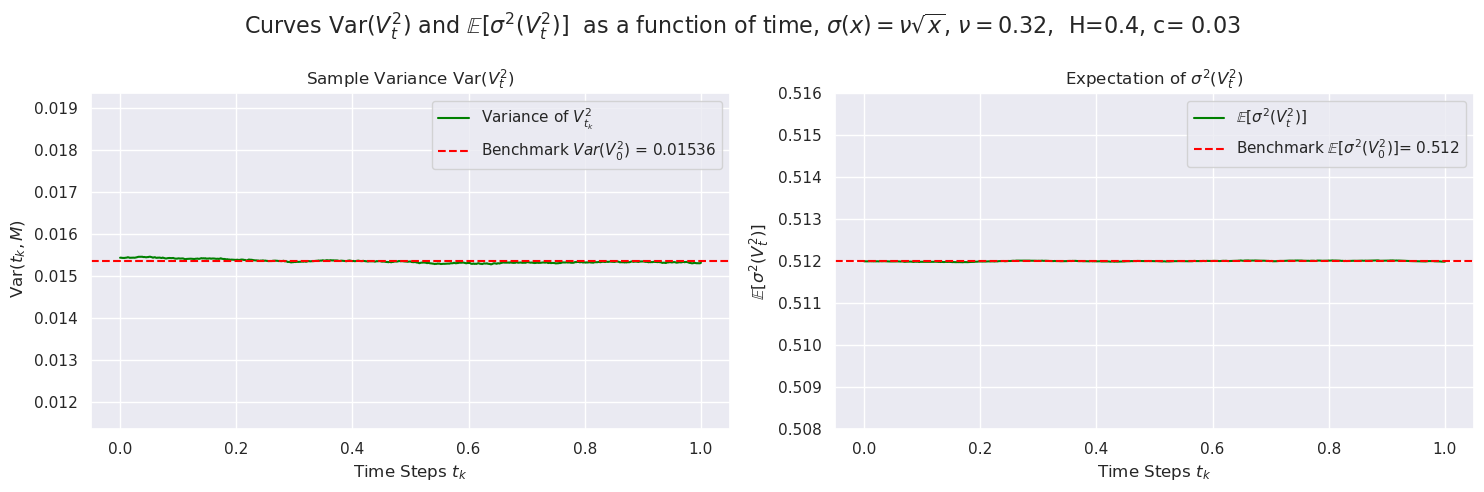

In [16]:
simulator.M = 90000
simulator.scheme = 2
expectation_sigma_square, variances, _, _ = simulator.simulate_batches_compute_moments_plot_trajectories(total_batches=40)
plot_variance_meansigma_curves(simulator, expectation_sigma_square, variances)

## Compute and plot the solution to Fractional Riccati Volterra Integral Equations(FRVIE)

In [17]:
def fractional_ABM_2D(f, t_grid, alpha):
    """
    Fractional Adams–Bashforth–Moulton scheme in dimension 2.

    Parameters
    ----------
    f : function
        f(t, y) -> (f1, f2)
    T : float
        terminal time
    n : int
        number of time steps
    alpha : array-like
        fractional orders [alpha1, alpha2]

    Returns
    -------
    t_grid : array
        time grid
    y : array (n+1,2)
        solution (psi1, psi2)
    """

    dt = t_grid[1]-t_grid[0]
    n= len(t_grid)-1
    # t = np.linspace(0, T, n+1)

    y = np.zeros((n+1, 2))   # y[:,0] = psi1 , y[:,1] = psi2
    y_pred = np.zeros(2)

    for i in range(2):

        alpha_i = alpha[i]

        for k in range(n):

            # ---------- Predictor ----------
            pred = 0.0

            for j in range(k+1):

                b = (dt**alpha_i / gamma(alpha_i+1)) * (
                    (k+1-j)**alpha_i - (k-j)**alpha_i
                )

                f1, f2 = f(t_grid[j], y[j])
                fij = f1 if i == 0 else f2

                pred += b * fij

            y_pred[i] = pred


            # ---------- Corrector ----------
            corr = 0.0

            for j in range(k+1):

                if j == 0:

                    a_weight = (dt**alpha_i / gamma(alpha_i+2)) * (
                        k**(alpha_i+1) - (k-alpha_i)*(k+1)**alpha_i
                    )

                else:

                    a_weight = (dt**alpha_i / gamma(alpha_i+2)) * (
                        (k-j+2)**(alpha_i+1)
                        + (k-j)**(alpha_i+1)
                        - 2*(k-j+1)**(alpha_i+1)
                    )

                f1, f2 = f(t_grid[j], y[j])
                fij = f1 if i == 0 else f2

                corr += a_weight * fij

            # term j = k+1
            f1p, f2p = f(t_grid[k+1], y_pred)
            f_pred = f1p if i == 0 else f2p

            a_last = dt**alpha_i / gamma(alpha_i+2)

            y[k+1, i] = corr + a_last * f_pred

    return y

In [19]:
def make_f(T, theta, rho, nu, D, varsigma, t_grid):
    """
    Builds f(t,psi) = a + F(T-t,psi)

    varsigma : array (n+1,2)
        σ^i(t_k) values
    """

    theta = np.asarray(theta)
    rho = np.asarray(rho)
    nu = np.asarray(nu)

    # ---- constant term a_i ----
    a = - theta**2 # / 2

    def f(t, psi):

        psi = np.asarray(psi)

        # argument of F
        s = T - t

        # index corresponding to s
        k = np.searchsorted(t_grid, s)
        k = min(k, len(t_grid)-1)

        sigma = varsigma[k]   # vector (σ¹, σ²)

        Dpsi = D.T @ psi

        F = np.zeros(2)

        for i in range(2):
            term1 = - 2*theta[i]*rho[i]*nu[i]*sigma[i]*psi[i]
            term3 = (nu[i]**2/2)*(1-2*rho[i]**2)*(sigma[i]*psi[i])**2

            F[i] = term1 + Dpsi[i] + term3

        return a + F

    return f

In [21]:
def compute_Riccati(solver, T, alpha, theta, rho, nu, D, varsigma, t_grid):
    """
    Compute solution of the Riccati Equation ψ.

    psi : array (n+1,2)
    varsigma : array (n+1,2)
    """
    n = len(t_grid) - 1
    psi = np.zeros((n+1, 2))
    f = make_f(
            T=T,
            theta=theta,
            rho=rho,
            nu=nu,
            D=D,
            varsigma=varsigma,
            t_grid=t_grid
        )
    return solver(f, t_grid, alpha)
    
def plot_Riccati_control_and_wealth(
    solver,
    T,
    n,
    alpha,
    theta,
    rho,
    nu,
    D,
    varsigma,
    t_grid,
    r, 
    c_star,
    X,
    m,
    mode="riccati"
):
    curves = ["strat", "wealth"]
    # -------- FIGURE CREATION --------
    if mode == "strategy":
        fig, axes = plt.subplots(1, 2, figsize=(15,5)) #  figsize=(14,5)
        # ----- Optimal control -----
        axes[0].plot(t_grid[:-1], c_star[:,0], label=r"$\alpha^{*,1}_t$")
        axes[0].plot(t_grid[:-1], c_star[:,1], label=r"$\alpha^{*,2}_t$")
        # labels = [r'$\pi^1,\; \alpha_1=$' + f'{alpha[0]}',
        #           r'$\pi^2,\; \alpha_2=$' + f'{alpha[1]}']
        axes[0].set_title("Optimal feedback control")
        axes[0].set_xlabel("Time")
        axes[0].set_ylabel(r"$\alpha_t^*$")
        axes[0].grid(True)
        axes[0].legend()
        # ----- Wealth process -----
        risklessX = X[0]*np.exp(r*t_grid)
        axes[1].plot(t_grid, X, label=r"$X_t^*$", color="black")
        axes[1].plot(t_grid, risklessX, label=r"riskless asset $X_0 e^{\int_0^t r(s)ds}$", color="red")
        # axes[1].plot(t_grid, [m]*len(t_grid), label="Expected terminal Wealth", color="orange")
        axes[1].axhline(m, color="orange", label="Expected terminal Wealth")
        axes[1].set_title("Evolution of wealth process")
        axes[1].set_xlabel("Time")
        axes[1].set_ylabel(r"$X_t$")
        axes[1].grid(True)
        axes[1].legend()  
    else:
        fig, ax = plt.subplots(figsize=(8,5))
        y = compute_Riccati(solver, T, alpha, theta, rho, nu, D, varsigma, t_grid)
        labels = [
            r'$\psi^1,\; \alpha_1=$' + f'{alpha[0]}',
            r'$\psi^2,\; \alpha_2=$' + f'{alpha[1]}'
        ]
        ylabel = r'$\psi(t)$'
        ax.plot(t_grid, y[:,0], label=labels[0])
        ax.plot(t_grid, y[:,1], label=labels[1])
        ax.set_title(
            f"Riccati solution ($\\rho_1$={rho[0]}, $\\rho_2$={rho[1]})"
        )
        ax.set_xlabel("Time")
        ax.set_ylabel(ylabel)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'FigSolutionPbmax_Mode{mode}_T{int(T)}.pdf')
    #  plt.savefig(f'FigOptStrat_WealthProcess_T{int(T)}.pdf')
    plt.show()

In [21]:
T = 1
N = 600
r=0.02
M= 3200 # 1
t_values = np.linspace(0, T, N+1)

theta = np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55]) #  np.array([-0.4, 0.25]) # np.array([-0.7,-0.55])
nu = np.array([0.4,0.32])
c_val = np.array([0.01, 0.01])
D = np.array([[-0.2,0],
              [0,-0.2]])
alpha = [0.5 + 0.1, 0.5 + 0.4]

# \varsigma(t)  # must computes at once, V = (V1, V2), W =(W1, W2) and varsigma, 
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['M'] = M
varsigma = np.zeros((N+1,2))
V_paths = np.zeros((2, N+1, M))
dW = np.zeros((2, N+1, M))

config['alpha'] = alpha[0] # 0.5 + 0.1,
config['lambda_'] = -D[0][0]
config['c'] = c_val[0]
config['mu_0'] = mu_01
config['sigma_x'] = lambda x : nu[0]*np.sqrt(x)
config['v0'] = -c_val[0]*nu[0]**2*mu_01 / D[0,0]
config['X0_distribution'] = {'type': 'normal', 'mean': -mu_01/D[0][0], 'std': np.sqrt(-c_val[0]*nu[0]**2*mu_01 / D[0,0]), }

config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H010.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H010.npz').toarray()}
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)
X, _, increments = simulator.simulate_path_cholesky_expanded()
V_paths[0], dW[0,:N, : ] = X, np.array(increments) # np.array(X).ravel(), np.array(increments).ravel()# X, _, increments = simulator.simulate_path_cholesky_expanded()

config['alpha'] = alpha[1] # 0.5 + 0.4,
config['lambda_'] = -D[1][1]
config['c'] = c_val[1]
config['mu_0'] = mu_02
config['sigma_x'] = lambda x : nu[1]*np.sqrt(x)
config['v0'] = -c_val[1]*nu[1]**2*mu_02 / D[1][1]
config['X0_distribution'] = {'type': 'normal', 'mean': -mu_02/D[1][1], 'std': np.sqrt(-c_val[1]*nu[1]**2*mu_02 / D[1][1]), }

config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)
# V[:,2], _, W[:,2] = simulator.simulate_path_cholesky_expanded() 
X2, _, increments2 = simulator.simulate_path_cholesky_expanded()
V_paths[1], dW[1,:N, : ] = X2, np.array(increments2) # np.array(X2).ravel(), np.array(increments2).ravel()

computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 10917.29it/s]


done: Rayon > T : Yes, [Rayon, T] = [249.27730107582335, 1]
Simulating trajectories, scheme 2


100%|████████████████████████████████████████| 600/600 [00:04<00:00, 123.44it/s]


done
computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 13598.78it/s]


done: Rayon > T : Yes, [Rayon, T] = [125.78637485851324, 1]
Simulating trajectories, scheme 2


100%|█████████████████████████████████████████| 600/600 [00:12<00:00, 46.51it/s]

done


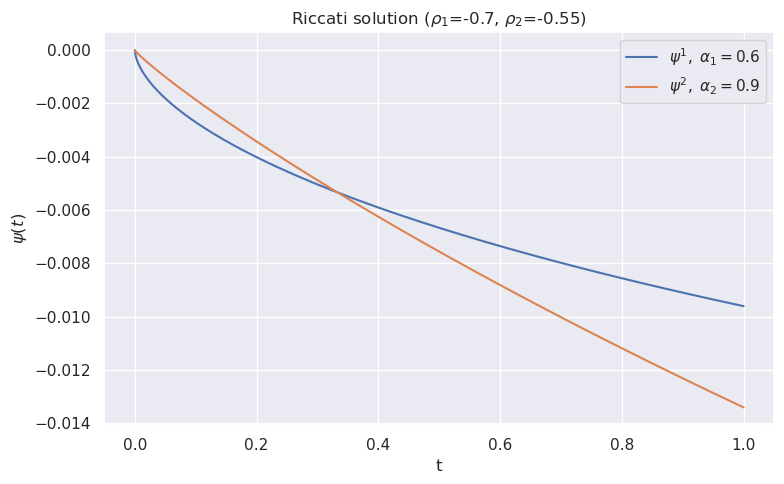

In [378]:
plot_Riccati_control_and_wealth(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha=alpha,
    theta=theta,
    rho=rho,
    nu=nu,
    D=D,
    varsigma=varsigma,
    t_grid=t_values, 
    r=r, 
    c_star=0, 
    X=0,
    mode="riccati"
)

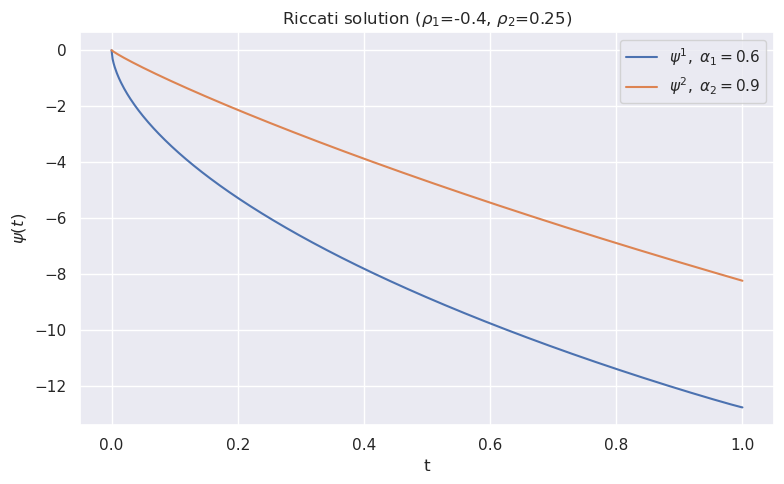

In [380]:
theta = np.array([3.6,3.0]) # np.array([4.7,3.4]) # np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.4, 0.25])  # np.array([-0.7,-0.55]) #  np.array([-0.4, 0.25]) # np.array([-0.7,-0.55])
plot_Riccati_control_and_wealth(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha=alpha,
    theta=theta,
    rho=rho,
    nu=nu,
    D=D,
    varsigma=varsigma,
    t_grid=t_values, 
    r=r, 
    c_star=0, 
    X=0,
    mode="riccati"
)
theta = np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55]) #  np.array([-0.4, 0.25]) # np.array([-0.7,-0.55])

## Compute and plot Optimal Strategy and optimal wealth process evolution

In [23]:
def compute_g0(t_grid, V0, mu0, alpha):
    """
    Compute g0(t) = V0 + mu0 * t^alpha / Gamma(alpha+1)
    
    Parameters
    ----------
    t_grid : array
    V0 : array-like (d,M)
    mu0 : array-like (d,)
    alpha : float
    
    Returns
    -------
    g0 : array shape (d,len(t_grid), M)
    """
    d, M = V0.shape # V0 is of the form (d, M)
    n = len(t_grid) - 1 
    g0 = np.zeros((d, n+1, M)) 
    
    alpha = np.asarray(alpha)  
    t_grid = np.asarray(t_grid)
    V0 = np.asarray(V0)
    mu0 = np.asarray(mu0)

    coef = 1.0 / gamma(alpha + 1)

    t_power = t_grid[:, None] ** alpha[None, :]  # (t_grid ** alpha)[:, None]  # shape (N,1)
    # (n+1, d)
    add_term = mu0 * coef * t_power

    # vectorisation totale
    g0 = V0[:, None, :] + add_term.T[:, :, None]   # (d, n+1, M)
    return g0
def compute_Gamma0(
    psi, T, t_grid, r, theta, rho, nu, D, varsigma,
    V0, mu0, alpha
):  
    """
    Compute Gamma_0
    
    Assumes existence of:
        make_f(T, theta, rho, nu, D, varsigma, t_grid)
        returning array shape (M, 1)
    """
    t_grid = np.asarray(t_grid)

    # ---- integral r
    int_r = r * T

    # ---- f(s)
    f_vals = np.zeros_like(psi)
    f_ = make_f(T, theta, rho, nu, D, varsigma, t_grid)

    for k, t in enumerate(t_grid):
        f_vals[k] = f_(t, psi[k])   # (n+1, d)

    # ---- g0
    g0_vals = compute_g0(t_grid, V0, mu0, alpha)   # (d, n+1, M)

    g0_vals = np.transpose(g0_vals, (1, 0, 2))  # (n+1, d, M)

    # produit élément par élément
    integrand = f_vals[:, :, None] * g0_vals   # (n+1, d, M)

    integral_t = np.trapz(integrand, t_grid, axis=0)   # (d, M) 
    # somme sur les facteurs
    sum_integral = np.sum(integral_t, axis=0)   # (M,)

    # ---- résultat final
    Gamma0 = np.exp(2 * int_r + sum_integral)

    return Gamma0
    
#def compute_xi_star(m, x0, Gamma0, r, T, t_grid):
#    dt = t_grid[1] - t_grid[0]
#    if np.isscalar(r):
#        integral_r = r * T
#    else:
#        integral_r = np.trapz(r, t_grid)
#    xi_star = (m - Gamma0*np.exp(-integral_r)*x0) / (1 - Gamma0*np.exp(-2*integral_r))
#    return xi_star
    
def compute_xi_star(m, x0, Gamma0, r, T, t_grid):
    if np.isscalar(r):
        integral_r = r * T
    else:
        integral_r = np.trapz(r, t_grid)

    disc = np.exp(-integral_r)

    xi_star = (m - Gamma0 * disc * x0) / (1 - Gamma0 * disc**2)
    return xi_star

In [154]:
mu0 = [mu_01,mu_02]
center = [center1, center2]
r=0.02
x0 = 2
m= x0*np.exp((r+0.1)*T)
print('Expected terminal wealth', m)
psi= compute_Riccati(fractional_ABM_2D, T, alpha, theta, rho, nu, D, varsigma, t_values)
g0_vals = compute_g0(t_values, V_paths[:,0,:], mu0,  alpha)
Gamma0 = compute_Gamma0(psi, T, t_values, r, theta, rho, nu, D, varsigma, V_paths[:,0,:], mu0,  alpha)
# %%% Gamma0 =Gamma_03 oops, look
xi_star = compute_xi_star(m, x0, Gamma0, r, T, t_values)
print(r'$\Gamma$ and $\xi$=', Gamma0, xi_star)

Expected terminal wealth 2.2549937031587515
$\Gamma$ and $\xi$= [0.91305718 0.9147998  0.91313465 ... 0.91197886 0.9113299  0.91320041] [3.78867958 3.8128567  3.78974025 ... 3.77404649 3.76535741 3.79064175]


In [25]:
def simulate_optimal_stratWealth(
    X0, 
    V,
    dW,
    psi,
    varsigma,
    t_grid,
    T,
    theta,
    rho,
    nu,
    xi_star,
    r
):
    n = len(t_grid) - 1  # Nombre de pas de temps
    d = 2  # Dimension
    dt = T / n  # Pas de temps
    # Déduire M (le nombre de trajectoires) à partir de la taille de V
    M = V.shape[2]  # V est de forme (d, n, M)

    # Initialiser X pour M trajectoires, forme (n+1, M)
    X = np.zeros((n + 1, M))  # X trajectoires, forme (n+1, M)
    X[0, :] = X0  # Initialisation de X_0 pour toutes les trajectoires
    c_star = np.zeros((d, n+1, M))  # Contrôles pour M trajectoires, forme (d, n, M)
    # Simuler dW_perp indépendants
    dW_perp = np.sqrt(dt)*rng.standard_normal((d, n, M)) # np.random.normal(0, np.sqrt(dt), (d, n, M))  # Incréments indépendants (d, n, M)
    # Boucle principale sur les pas de temps
    for k in range(n+1):
        t = t_grid[k]
        # Index pour ψ(T - t)
        s = T - t
        j = np.searchsorted(t_grid, s)
        j = min(j, n)

        if np.isscalar(r):
            disc = np.exp(-r * (T - t))  # Facteur d'actualisation
            r_t = r
        else:
            disc = np.exp(-np.trapz(r[k:], t_grid[k:]))  # Facteur d'actualisation (intégré sur le temps)
            r_t = r[k]
        # Calcul du contrôle optimal pour chaque trajectoire
        for i in range(d):
            base = theta[i] + rho[i] * nu[i] * varsigma[k, i] * psi[j, i]
            c_star[i, k, :] = - base * np.sqrt(V[i, k, :]) * (X[k, :] - xi_star * disc)
        # Terme de dérive : r_t * X[k] - somme des contrôles
        if k==n:
            break
        drift = r_t * X[k, :] + np.sum(c_star[:, k, :] * (theta[:, np.newaxis] * np.sqrt(V[:, k, :])), axis=0)      # - np.dot(c_star[:, k, :], theta[:, np.newaxis] * V[:, k, :]).sum(axis=1)
        # Terme de diffusion : prendre en compte à la fois dW et dW_perp pour chaque trajectoire
        diffusion = np.zeros(M)
        for i in range(d):
            diffusion += (
                rho[i] * dW[i, k, :]
                - np.sqrt(1 - rho[i]**2) * dW_perp[i, k, :]
            ) * c_star[i, k, :]
        # Mise à jour de la richesse : X[k+1] = X[k] + drift * dt + diffusion
        X[k + 1, :] = X[k, :] + drift * dt + diffusion
    return X, c_star

In [33]:
mu0 = [mu_01,mu_02]
center = [center1, center2]
r=0.02
x0 = 2
m= x0*np.exp((r+0.1)*T)
print('Expected terminal wealth', m)

psi= compute_Riccati(fractional_ABM_2D, T, alpha, theta, rho, nu, D, varsigma, t_values)
Gamma0 = compute_Gamma0(psi, T, t_values, r, theta, rho, nu, D, varsigma, V_paths[:,0,:], mu0,  alpha)
xi_star = compute_xi_star(m, x0, Gamma0, r, T, t_values)

Expected terminal wealth 2.2549937031587515


In [35]:
X_wlth, c_star = simulate_optimal_stratWealth(
    X0=x0, # m=m,
    V=V_paths,
    dW=dW,
    psi=psi,
    varsigma=varsigma,
    t_grid=t_values,
    T=T,
    theta=theta,
    rho=rho,
    nu=nu,
    xi_star=xi_star,
    r=r
)

In [34]:
# ll_values = range(350, 560)  # choose the range you want

#for ll in ll_values:
#    print(ll)
#    plot_Riccati_control_and_wealth(
#        solver=fractional_ABM_2D,
#        T=T,
#        n=N,
#        alpha=alpha,
#        theta=theta,
#        rho=rho,
#        nu=nu,
#        D=D,
#        varsigma=varsigma,
#        t_grid=t_values, 
#        r=r, 
#        c_star=c_star[:, :600, ll].T, 
#        X=X_wlth[:, ll],
#        m=m,
#        mode="strategy"
#    )

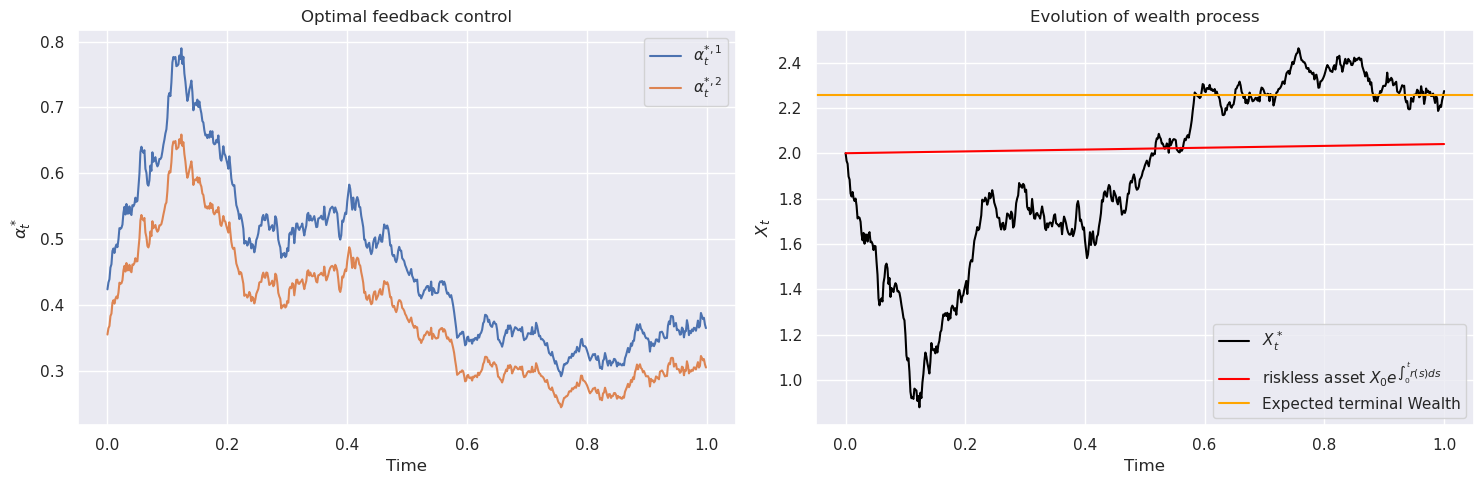

In [71]:
ll=76
plot_Riccati_control_and_wealth(
    solver=fractional_ABM_2D,
    T=T,
    n=N,
    alpha=alpha,
    theta=theta,
    rho=rho,
    nu=nu,
    D=D,
    varsigma=varsigma,
    t_grid=t_values, 
    r=r, 
    c_star=c_star[:,:600,ll].T, 
    X=X_wlth[:,ll],
    m=m,
    mode="strategy"
)

In [27]:
def bootstrap_CI(data, n_bootstrap=1000, ci=0.95):
    """
    Bootstrap method to calculate the confidence interval.
    
    :param data: The data from which to bootstrap.
    :param n_bootstrap: The number of bootstrap samples.
    :param ci: The desired confidence interval (default 95%).
    
    :return: The lower and upper bounds of the confidence interval.
    """
    bootstrap_samples = np.random.choice(data, (n_bootstrap, len(data)), replace=True)
    bootstrap_means = bootstrap_samples.mean(axis=1)
    lower = np.percentile(bootstrap_means, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrap_means, (1 + ci) / 2 * 100)
    return lower, upper

def plot_statistics(X, c_star, t_grid, n_bootstrap=1000, ci=0.95):
    """
    Plot the mean and 95% CI of wealth and strategy on separate subplots.
    
    :param X: The wealth trajectories (shape: (n+1, M))
    :param c_star: The strategy trajectories (shape: (n, M, d))
    :param t_grid: The time grid (shape: (n+1,))
    :param n_bootstrap: The number of bootstrap samples (default 1000).
    :param ci: The desired confidence interval (default 95%).
    """
    # Calculate mean wealth over all paths at each time step
    mean_X = X.mean(axis=1)
    
    # Calculate the 95% confidence interval for wealth
    lower_CI_X, upper_CI_X = np.zeros_like(mean_X), np.zeros_like(mean_X)
    for k in range(len(t_grid)):
        lower_CI_X[k], upper_CI_X[k] = bootstrap_CI(X[k, :], n_bootstrap, ci)

    # Calculate mean strategy for each time step and each dimension
    mean_strategy = c_star.mean(axis=2)  # Mean along the paths axis (M)
    
    # Initialize arrays to store CI bounds for each strategy dimension
    lower_CI_strategy = np.zeros_like(mean_strategy)
    upper_CI_strategy = np.zeros_like(mean_strategy)
    
    # Calculate the 95% confidence interval for strategy, loop over dimensions (d)
    for k in range(len(t_grid)):
        for dim in range(c_star.shape[0]):  # Loop over strategy dimensions (d)
            lower_CI_strategy[dim, k], upper_CI_strategy[dim, k] = bootstrap_CI(c_star[dim, k, :], n_bootstrap, ci)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot Wealth (Left Subplot)
    ax2.plot(t_grid, mean_X, label=r"Mean Wealth $X^{*}_t$", color='b', lw=2)
    ax2.fill_between(t_grid, lower_CI_X, upper_CI_X, color='b', alpha=0.2, label="95% CI (Bootstrap)")
    ax2.axhline(m, color="orange", label="Expected terminal Wealth")
    ax2.set_title('Wealth Evolution with 95% Confidence Interval (Bootstrapped)')
    ax2.set_xlabel('Time')
    ax2.set_ylabel(r"Wealth $X_t^*$")
    ax2.legend()
    ax2.grid(True)

    # Plot Strategy (Right Subplot)
    for dim in range(mean_strategy.shape[0]):  # Loop over strategy dimensions (d)
        ax1.plot(t_grid, mean_strategy[dim, :], label = r"Mean $\alpha^{*, " + str(dim+1) + "}_t$", lw=2)
        ax1.fill_between(t_grid, lower_CI_strategy[dim, :], upper_CI_strategy[dim, :], alpha=0.2)  # 95% CI shaded
    ax1.set_title('Optimal feedback control with 95% CI (Bootstrapped)')
    ax1.set_xlabel('Time')
    ax1.set_ylabel(r"Strategy $\alpha_t^*$")
    ax1.legend()
    ax1.grid(True)

    plt.tight_layout()
    plt.savefig(f'FigOptStrat_WealthProcessBootstrapped_T{int(T)}.pdf')
    plt.show()

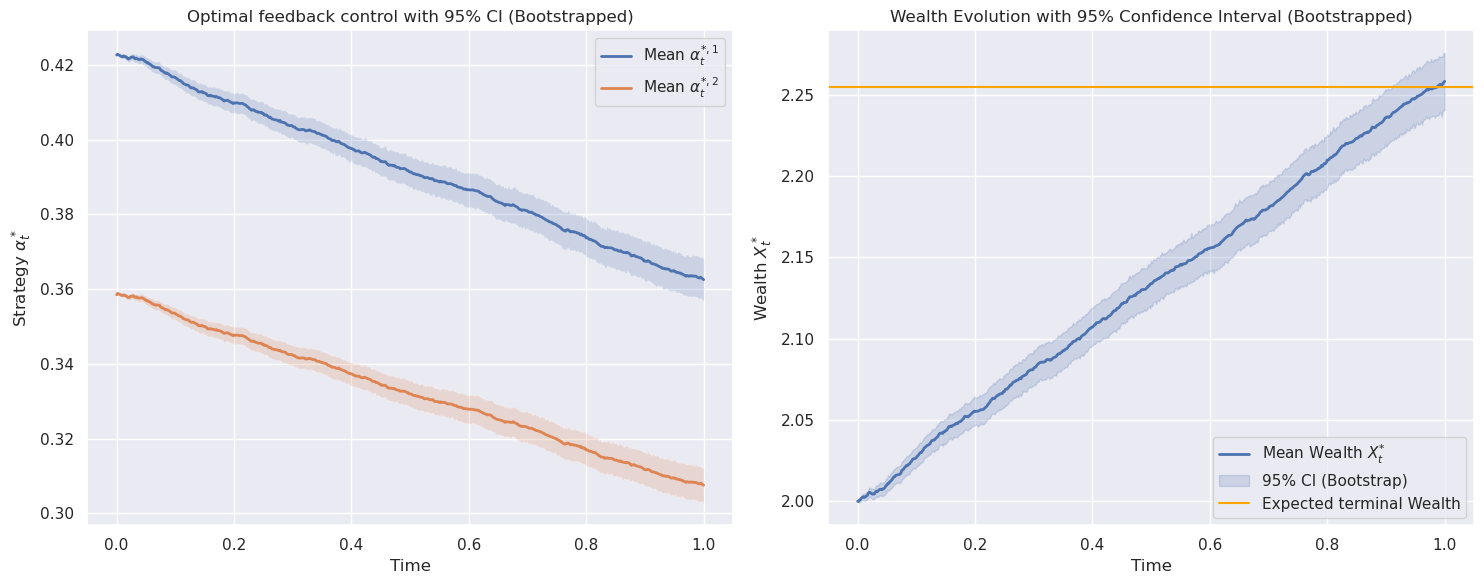

In [336]:
# Plot the statistics (mean and 95% CI) for wealth and strategy
plot_statistics(X_wlth, c_star, t_values)

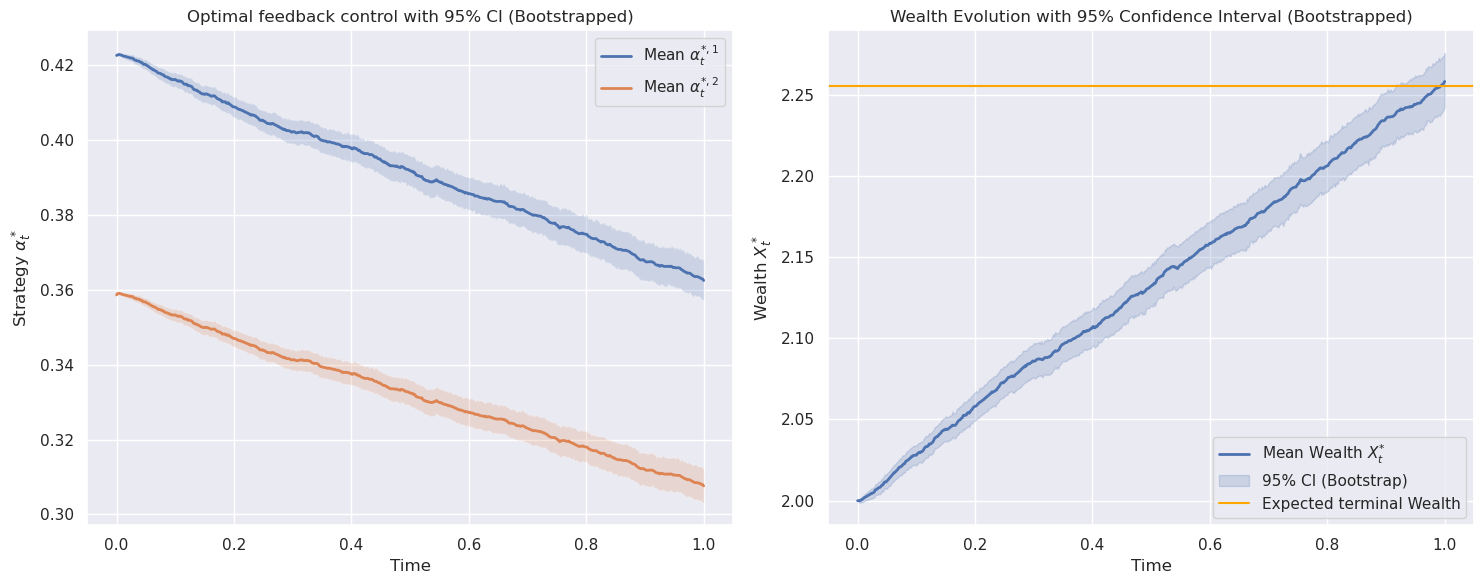

In [43]:
# Plot the statistics (mean and 95% CI) for wealth and strategy
plot_statistics(X_wlth, c_star, t_values)

## Compute and plot theoretical and empirical efficient frontier

In [29]:
def compute_and_plot_frontier(
    x0,
    T,
    r,
    Gamma0,
    t_grid,
    V_paths,
    dW,
    psi,
    varsigma,
    theta,
    rho,
    nu,
    n_points=50
):
    """
    Compute and plot theoretical and empirical efficient frontier
    """

    # ===== 1. Integral of r =====
    if callable(r):
        integral_r = np.trapz(r(t_grid), t_grid)
        r0 = r(0)
    else:
        integral_r = r * T
        r0 = r

    exp_r = np.exp(integral_r)

    # ===== 2. Theoretical frontier =====
    Gamma0_ =  np.mean(Gamma0) # Gamma0[1000] #
    A = x0 * exp_r
    B = np.sqrt(exp_r**2 / Gamma0_ - 1)

    if B <= 0:
       raise ValueError("No feasible efficient frontier: check Gamma0")

    # Range for m
    m_min = x0 * np.exp((r0 + 0.01) * T)
    m_max = x0 * np.exp((r0 + 0.5) * T)
    m_vals = np.linspace(m_min, m_max, n_points)

    # Theoretical sigma
    sigma_theo = (m_vals - A) / B

    # ===== 3. Empirical frontier =====
    sigma_emp = np.zeros(n_points)

    for k, m_ in enumerate(m_vals):   # correction enumerate

        xi_star = compute_xi_star(m_, x0, Gamma0, r, T, t_grid)

        X_wlth, _ = simulate_optimal_stratWealth(
            X0=x0,
            V=V_paths,
            dW=dW,
            psi=psi,
            varsigma=varsigma,
            t_grid=t_grid,
            T=T,
            theta=theta,
            rho=rho,
            nu=nu,
            xi_star=xi_star,
            r=r
        )

        # terminal wealth
        X_T = X_wlth[-1]

        # frontier uses std, not variance
        sigma_emp[k] = np.std(X_T)

    # ===== 4. Plot =====
    plt.figure(figsize=(7, 5))

    # Theoretical
    plt.plot(m_vals, sigma_theo,  label="Theoretical", color="blue")

    # Empirical
    plt.scatter(m_vals, sigma_emp, label="Empirical", color="red", s=20)

    plt.ylabel(r"Standard deviation $\sqrt{Var(X_T^*)}$")
    plt.xlabel("Mean (m)")
    plt.title(f"Efficient Frontier T={T}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'FigEfficientFrontier_T{int(T)}.pdf')
    plt.show()

    return sigma_theo, sigma_emp, m_vals

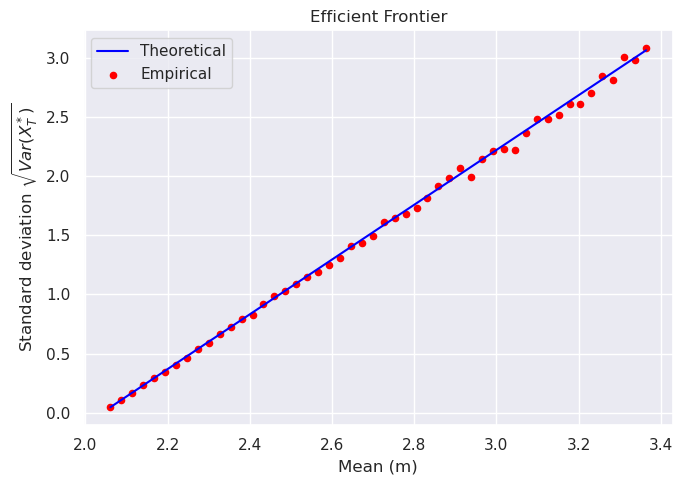

In [47]:
# T= 1
sigma_theo, sigma_emp, m_vals = compute_and_plot_frontier(
    x0, T, r, Gamma0,
    t_values,
    V_paths,
    dW,
    psi,
    varsigma,
    theta,
    rho,
    nu
)

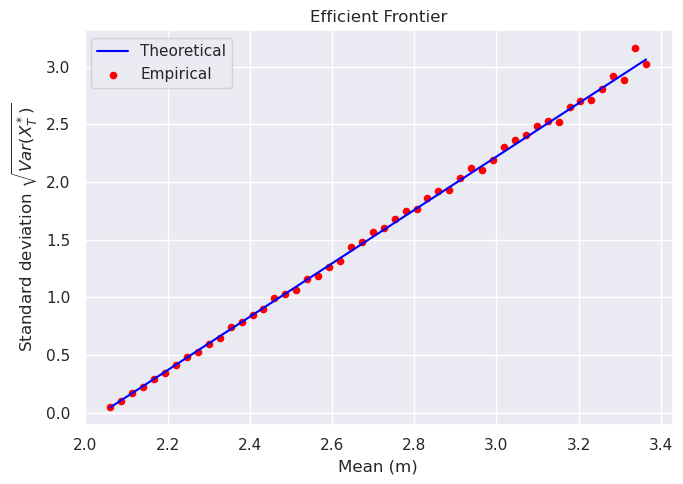

In [332]:
# T= 0.5, T=2, T=5/10
sigma_theo, sigma_emp, m_vals = compute_and_plot_frontier(
    x0, T, r, Gamma0,
    t_values,
    V_paths,
    dW,
    psi,
    varsigma,
    theta,
    rho,
    nu
)

In [32]:
T = 0.5
N = 600
r=0.02
M= 3200 # 1
t_values = np.linspace(0, T, N+1)

theta = np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55]) #  np.array([-0.4, 0.25]) # np.array([-0.7,-0.55])
nu = np.array([0.4,0.32])
c_val = np.array([0.01, 0.01])
D = np.array([[-0.2,0],
              [0,-0.2]])
alpha = [0.5 + 0.1, 0.5 + 0.4]

# \varsigma(t)  # must computes at once, V = (V1, V2), W =(W1, W2) and varsigma, 
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['M'] = M
config['scheme'] = 3
varsigma = np.zeros((N+1,2))
V_paths = np.zeros((2, N+1, M))
dW = np.zeros((2, N+1, M))

config['alpha'] = alpha[0] # 0.5 + 0.1,
config['lambda_'] = -D[0][0]
config['c'] = c_val[0]
config['mu_0'] = mu_01
config['sigma_x'] = lambda x : nu[0]*np.sqrt(x)
config['v0'] = -c_val[0]*nu[0]**2*mu_01 / D[0,0]
config['X0_distribution'] = {'type': 'normal', 'mean': -mu_01/D[0][0], 'std': np.sqrt(-c_val[0]*nu[0]**2*mu_01 / D[0,0]), }

config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H010.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H010.npz').toarray()}
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)
X, _, increments = simulator.simulate_path_cholesky_expanded_2()
V_paths[0], dW[0,:N, : ] = X, np.array(increments) # np.array(X).ravel(), np.array(increments).ravel()# X, _, increments = simulator.simulate_path_cholesky_expanded()

config['alpha'] = alpha[1] # 0.5 + 0.4,
config['lambda_'] = -D[1][1]
config['c'] = c_val[1]
config['mu_0'] = mu_02
config['sigma_x'] = lambda x : nu[1]*np.sqrt(x)
config['v0'] = -c_val[1]*nu[1]**2*mu_02 / D[1][1]
config['X0_distribution'] = {'type': 'normal', 'mean': -mu_02/D[1][1], 'std': np.sqrt(-c_val[1]*nu[1]**2*mu_02 / D[1][1]), }

config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)
# V[:,2], _, W[:,2] = simulator.simulate_path_cholesky_expanded() 
X2, _, increments2 = simulator.simulate_path_cholesky_expanded_2()
V_paths[1], dW[1,:N, : ] = X2, np.array(increments2) # np.array(X2).ravel(), np.array(increments2).ravel()

computing tauberian coefficients


100%|█████████████████████████████████████████| 74/74 [00:00<00:00, 6466.49it/s]


done: Rayon > T : Yes, [Rayon, T] = [249.27730107582335, 0.5]
computing VCV matrix, scheme 3


100%|████████████████████████████████████████| 599/599 [00:01<00:00, 307.71it/s]


done
Simulating trajectories, scheme 3


...

done: Rayon > T : Yes, [Rayon, T] = [125.78637485851324, 0.5]
computing VCV matrix, scheme 3


100%|████████████████████████████████████████| 599/599 [00:01<00:00, 317.48it/s]


done
Simulating trajectories, scheme 3


100%|█████████████████████████████████████████| 600/600 [00:19<00:00, 30.03it/s]


done


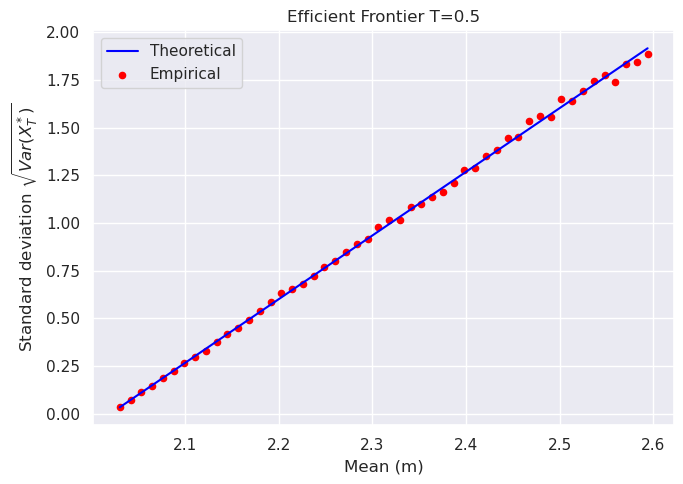

In [40]:
mu0 = [mu_01, mu_02]
center = [center1, center2]
r=0.02
x0 = 2
m= x0*np.exp((r+0.1)*T)
print('Expected terminal wealth', m)

psi= compute_Riccati(fractional_ABM_2D, T, alpha, theta, rho, nu, D, varsigma, t_values)
Gamma0 = compute_Gamma0(psi, T, t_values, r, theta, rho, nu, D, varsigma, V_paths[:,0,:], mu0,  alpha)
xi_star = compute_xi_star(m, x0, Gamma0, r, T, t_values)

# T= 0.5
sigma_theo, sigma_emp, m_vals = compute_and_plot_frontier(
    x0, T, r, Gamma0,
    t_values,
    V_paths,
    dW,
    psi,
    varsigma,
    theta,
    rho,
    nu
)

In [33]:
T = 3
N = 600
r=0.02
M=  1300 # 1
t_values = np.linspace(0, T, N+1)

theta = np.array([0.1,0.12]) # theta = np.array([0.1,0.2])
rho = np.array([-0.7,-0.55]) #  np.array([-0.4, 0.25]) # np.array([-0.7,-0.55])
nu = np.array([0.4,0.32])
c_val = np.array([0.01, 0.01])
D = np.array([[-0.2,0],
              [0,-0.2]])
alpha = [0.5 + 0.1, 0.5 + 0.4]

# \varsigma(t)  # must computes at once, V = (V1, V2), W =(W1, W2) and varsigma, 
# Instantiate and run the simulator
config['T'] = T
config['n'] = N
config['M'] = M
config['scheme'] = 3
varsigma = np.zeros((N+1,2))
V_paths = np.zeros((2, N+1, 3*M))
dW = np.zeros((2, N+1, 3*M))

config['alpha'] = alpha[0] # 0.5 + 0.1,
config['lambda_'] = -D[0][0]
config['c'] = c_val[0]
config['mu_0'] = mu_01
config['sigma_x'] = lambda x : nu[0]*np.sqrt(x)
config['v0'] = -c_val[0]*nu[0]**2*mu_01 / D[0,0]
config['X0_distribution'] = {'type': 'normal', 'mean': -mu_01/D[0][0], 'std': np.sqrt(-c_val[0]*nu[0]**2*mu_01 / D[0,0]), }

config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H010.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H010.npz').toarray()}
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,0] = simulator.zeta_t(t_values, simulator.c_coeffs)
X, _, increments = simulator.simulate_path_cholesky_expanded_2()
V_paths[0,:,:M], dW[0,:N, :M ] = X, np.array(increments) # np.array(X).ravel(), np.array(increments).ravel()# X, _, increments = simulator.simulate_path_cholesky_expanded()

X_, _, increments_ = simulator.simulate_path_cholesky_expanded_2()
V_paths[0,:,M:2*M], dW[0,:N, M: 2*M ] = X_, np.array(increments_) # np.array(X).ravel(), np.array(increments).ravel()# X, _, increments = simulator.simulate_path_cholesky_expanded()

X_, _, increments_ = simulator.simulate_path_cholesky_expanded_2()
V_paths[0,:,2*M:], dW[0,:N, 2*M: ] = X_, np.array(increments_) # np.array(X).ravel(), np.array(increments).ravel()# X, _, increments = simulator.simulate_path_cholesky_expanded()


config['alpha'] = alpha[1] # 0.5 + 0.4,
config['lambda_'] = -D[1][1]
config['c'] = c_val[1]
config['mu_0'] = mu_02
config['sigma_x'] = lambda x : nu[1]*np.sqrt(x)
config['v0'] = -c_val[1]*nu[1]**2*mu_02 / D[1][1]
config['X0_distribution'] = {'type': 'normal', 'mean': -mu_02/D[1][1], 'std': np.sqrt(-c_val[1]*nu[1]**2*mu_02 / D[1][1]), }

config['VCV'] = {'T_expanded': sp_sparse.load_npz('T_matrix_H040.0.npz').toarray(),'D_expanded':sp_sparse.load_npz('D_matrix_H040.0.npz').toarray()}
simulator = StochasticProcessSimulator(config, random_state=rng)
varsigma[:,1] = simulator.zeta_t(t_values, simulator.c_coeffs)
# V[:,2], _, W[:,2] = simulator.simulate_path_cholesky_expanded() 
X2, _, increments2 = simulator.simulate_path_cholesky_expanded_2()
V_paths[1,:,:M], dW[1,:N, :M] = X2, np.array(increments2) # np.array(X2).ravel(), np.array(increments2).ravel()

X2_, _, increments2_ = simulator.simulate_path_cholesky_expanded_2()
V_paths[1,:, M:2*M], dW[1,:N, M:2*M] = X2_, np.array(increments2_) # np.array(X2).ravel(), np.array(increments2).ravel()

X2_, _, increments2_ = simulator.simulate_path_cholesky_expanded_2()
V_paths[1,:, 2*M:], dW[1,:N, 2*M:] = X2_, np.array(increments2_) # np.array(X2).ravel(), np.array(increments2).ravel()

computing tauberian coefficients


100%|████████████████████████████████████████| 74/74 [00:00<00:00, 30576.15it/s]


done: Rayon > T : Yes, [Rayon, T] = [249.27730107582335, 3]
computing VCV matrix, scheme 3


100%|████████████████████████████████████████| 599/599 [00:00<00:00, 751.93it/s]


done
Simulating trajectories, scheme 3


...

done
Simulating trajectories, scheme 3


100%|████████████████████████████████████████| 600/600 [00:02<00:00, 234.09it/s]


done
Simulating trajectories, scheme 3


100%|████████████████████████████████████████| 600/600 [00:04<00:00, 123.87it/s]


done


Expected terminal wealth 2.8666588291206807


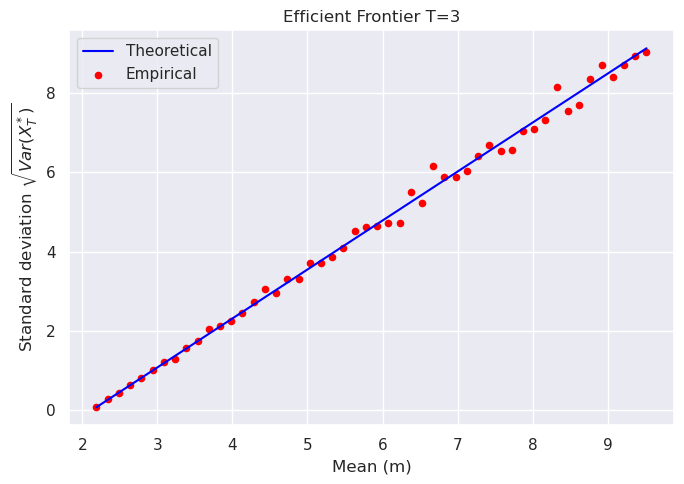

In [35]:
mu0 = [mu_01, mu_02]
center = [center1, center2]
r=0.02
x0 = 2
m= x0*np.exp((r+0.1)*T)
print('Expected terminal wealth', m)

psi= compute_Riccati(fractional_ABM_2D, T, alpha, theta, rho, nu, D, varsigma, t_values)
Gamma0 = compute_Gamma0(psi, T, t_values, r, theta, rho, nu, D, varsigma, V_paths[:,0,:], mu0,  alpha)
xi_star = compute_xi_star(m, x0, Gamma0, r, T, t_values)

# T= 5  # T= 0.5, T=1/2, T=5/10
sigma_theo, sigma_emp, m_vals = compute_and_plot_frontier(
    x0, T, r, Gamma0,
    t_values,
    V_paths,
    dW,
    psi,
    varsigma,
    theta,
    rho,
    nu
)

Expected terminal wealth 3.644237600781018


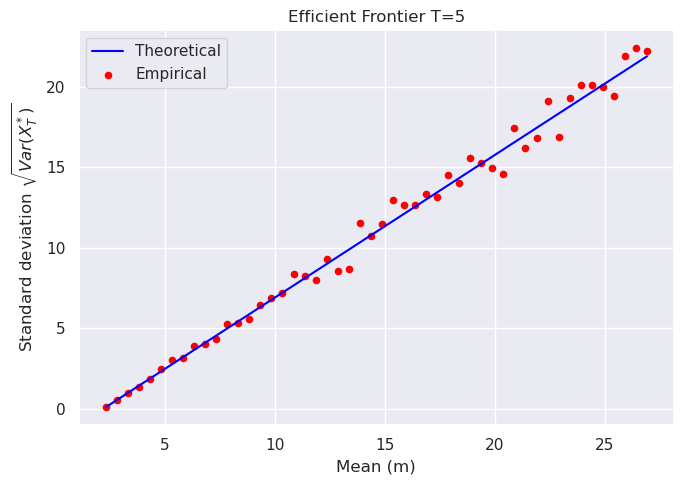

In [33]:
mu0 = [mu_01, mu_02]
center = [center1, center2]
r=0.02
x0 = 2
m= x0*np.exp((r+0.1)*T)
print('Expected terminal wealth', m)

psi= compute_Riccati(fractional_ABM_2D, T, alpha, theta, rho, nu, D, varsigma, t_values)
Gamma0 = compute_Gamma0(psi, T, t_values, r, theta, rho, nu, D, varsigma, V_paths[:,0,:], mu0,  alpha)
xi_star = compute_xi_star(m, x0, Gamma0, r, T, t_values)

# T= 5  # T= 0.5, T=1/2, T=5/10
sigma_theo, sigma_emp, m_vals = compute_and_plot_frontier(
    x0, T, r, Gamma0,
    t_values,
    V_paths,
    dW,
    psi,
    varsigma,
    theta,
    rho,
    nu
)

## References

[1] Emmanuel Gnabeyeu. (2026) *On the mean-variance problem through the lens of
multivariate fake stationary affine Volterra dynamics.*

[2] Emmanuel Gnabeyeu. (2026) *On Utility Maximization under Multivariate Fake Stationary Affine Volterra Models.*

[3] Emmanuel Gnabeyeu, Gilles Pagès and Mathieu Rosenbaum. (2025) *On Inhomogeneous Affine Volterra Processes: Stationarity
and Applications to the Volterra Heston Model.*

[4] Emmanuel Gnabeyeu and Gilles Pagès. (2025) *On a Stationarity Theory for Stochastic Volterra Integral
Equations.*